# Vertex AI Project 1 — Hello Vertex: Deploy a Tiny Model and Predict

## Overview
This notebook demonstrates a complete end-to-end MLOps workflow using Google Cloud's Vertex AI platform. We'll build, deploy, and serve a machine learning model for real-time and batch predictions.

## Learning Objectives
By the end of this notebook, you will understand how to:
1. **Train** a scikit-learn model locally using the Iris dataset
2. **Upload** the model to Vertex AI Model Registry
3. **Deploy** the model to a Vertex AI Endpoint for online predictions
4. **Serve** both online (real-time) and batch predictions
5. **Monitor** model performance and logs
6. **Clean up** resources to avoid unnecessary charges

## Prerequisites
- Google Cloud Project with Vertex AI API enabled
- Appropriate IAM permissions for Vertex AI operations
- Python environment with required packages


## 1. Environment Setup and Prerequisites

Before we begin, we need to install the required packages and verify our environment is properly configured.


In [1]:
# Install required packages
!pip install --upgrade pip
!pip install packaging setuptools wheel

# Install core ML and Google Cloud packages
# Note: Pinning scikit-learn to 1.4.x for compatibility with Vertex AI serving container
!pip -q install -U google-cloud-aiplatform "scikit-learn~=1.4.0" joblib google-cloud-storage


In [2]:
# Verify package installations and versions
!pip show scikit-learn google-cloud-aiplatform joblib


Name: scikit-learn
Version: 1.4.2
Summary: A set of python modules for machine learning and data mining
Home-page: https://scikit-learn.org
Author: 
Author-email: 
License: new BSD
Location: /usr/local/lib/python3.11/dist-packages
Requires: joblib, numpy, scipy, threadpoolctl
Required-by: cuml-cu12, fastai, hdbscan, imbalanced-learn, libpysal, librosa, mlxtend, pynndescent, sentence-transformers, shap, sklearn-compat, sklearn-pandas, tsfresh, umap-learn, yellowbrick
---
Name: google-cloud-aiplatform
Version: 1.120.0
Summary: Vertex AI API client library
Home-page: https://github.com/googleapis/python-aiplatform
Author: Google LLC
Author-email: googleapis-packages@google.com
License: Apache 2.0
Location: /usr/local/lib/python3.11/dist-packages
Requires: docstring_parser, google-api-core, google-auth, google-cloud-bigquery, google-cloud-resource-manager, google-cloud-storage, google-genai, packaging, proto-plus, protobuf, pydantic, shapely, typing_extensions
Required-by: 
---
Name: jobli

## 2. Configure the Environment

Now we'll set up our project configuration, including Google Cloud project details and create necessary directories for our model artifacts.


In [3]:

# Import required libraries
from google.cloud import aiplatform, storage
import joblib
import os
import json
import time
import uuid
import pathlib
import pickle
import sklearn
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier

# Project configuration
PROJECT_ID = "instr-cs795-fall25-hqin-1"
LOCATION = "us-east4"
BUCKET = "gs://instr-cs795-fall25-hqin-1-arasm002"

# Generate unique identifiers for this run
TIMESTAMP = time.strftime("%Y%m%d-%H%M%S")
DISPLAY_NAME = f"iris-rf-sklearn-{TIMESTAMP}"

# Directory and file paths
MODEL_DIR = f"model-artifacts-{TIMESTAMP}"
MODEL_FILE = f"{MODEL_DIR}/model.pkl"
BATCH_INPUT_DIR = f"batch_inputs_{TIMESTAMP}"

# GCS paths for batch processing
GCS_INPUT_PREFIX = f"{BUCKET}/batch_inputs/{TIMESTAMP}/"
GCS_OUTPUT_PREFIX = f"{BUCKET}/batch_outputs/{TIMESTAMP}/"

# Display configuration
print("=== Project Configuration ===")
print(f"Project ID: {PROJECT_ID}")
print(f"Location: {LOCATION}")
print(f"Storage Bucket: {BUCKET}")
print(f"Timestamp: {TIMESTAMP}")
print(f"Model Display Name: {DISPLAY_NAME}")


=== Project Configuration ===
Project ID: instr-cs795-fall25-hqin-1
Location: us-east4
Storage Bucket: gs://instr-cs795-fall25-hqin-1-arasm002
Timestamp: 20251009-024931
Model Display Name: iris-rf-sklearn-20251009-024931


### 2.1 Verify scikit-learn Version

Let's confirm the version of scikit-learn loaded in the environment before training. It should be `1.4.x` to match the Vertex AI serving container requirements.


### 2.2 Logging and Monitoring Setup

> **Note**: Logging access requires appropriate IAM permissions. If you encounter permission errors, ensure your account has the necessary roles.

Vertex AI automatically sends container logs to **Cloud Logging**. You can also enable **access logging** for detailed request/response monitoring:

- **Container Logs**: Go to **Cloud Console → Logging → Logs Explorer** and filter by your endpoint or model resource name
- **Access Logs**: Enable on the Endpoint's **Monitoring** tab for request/response metadata
- **Model Performance**: Monitor prediction latency, throughput, and error rates


Once I received these perms from Terry, I was able to find the problem:

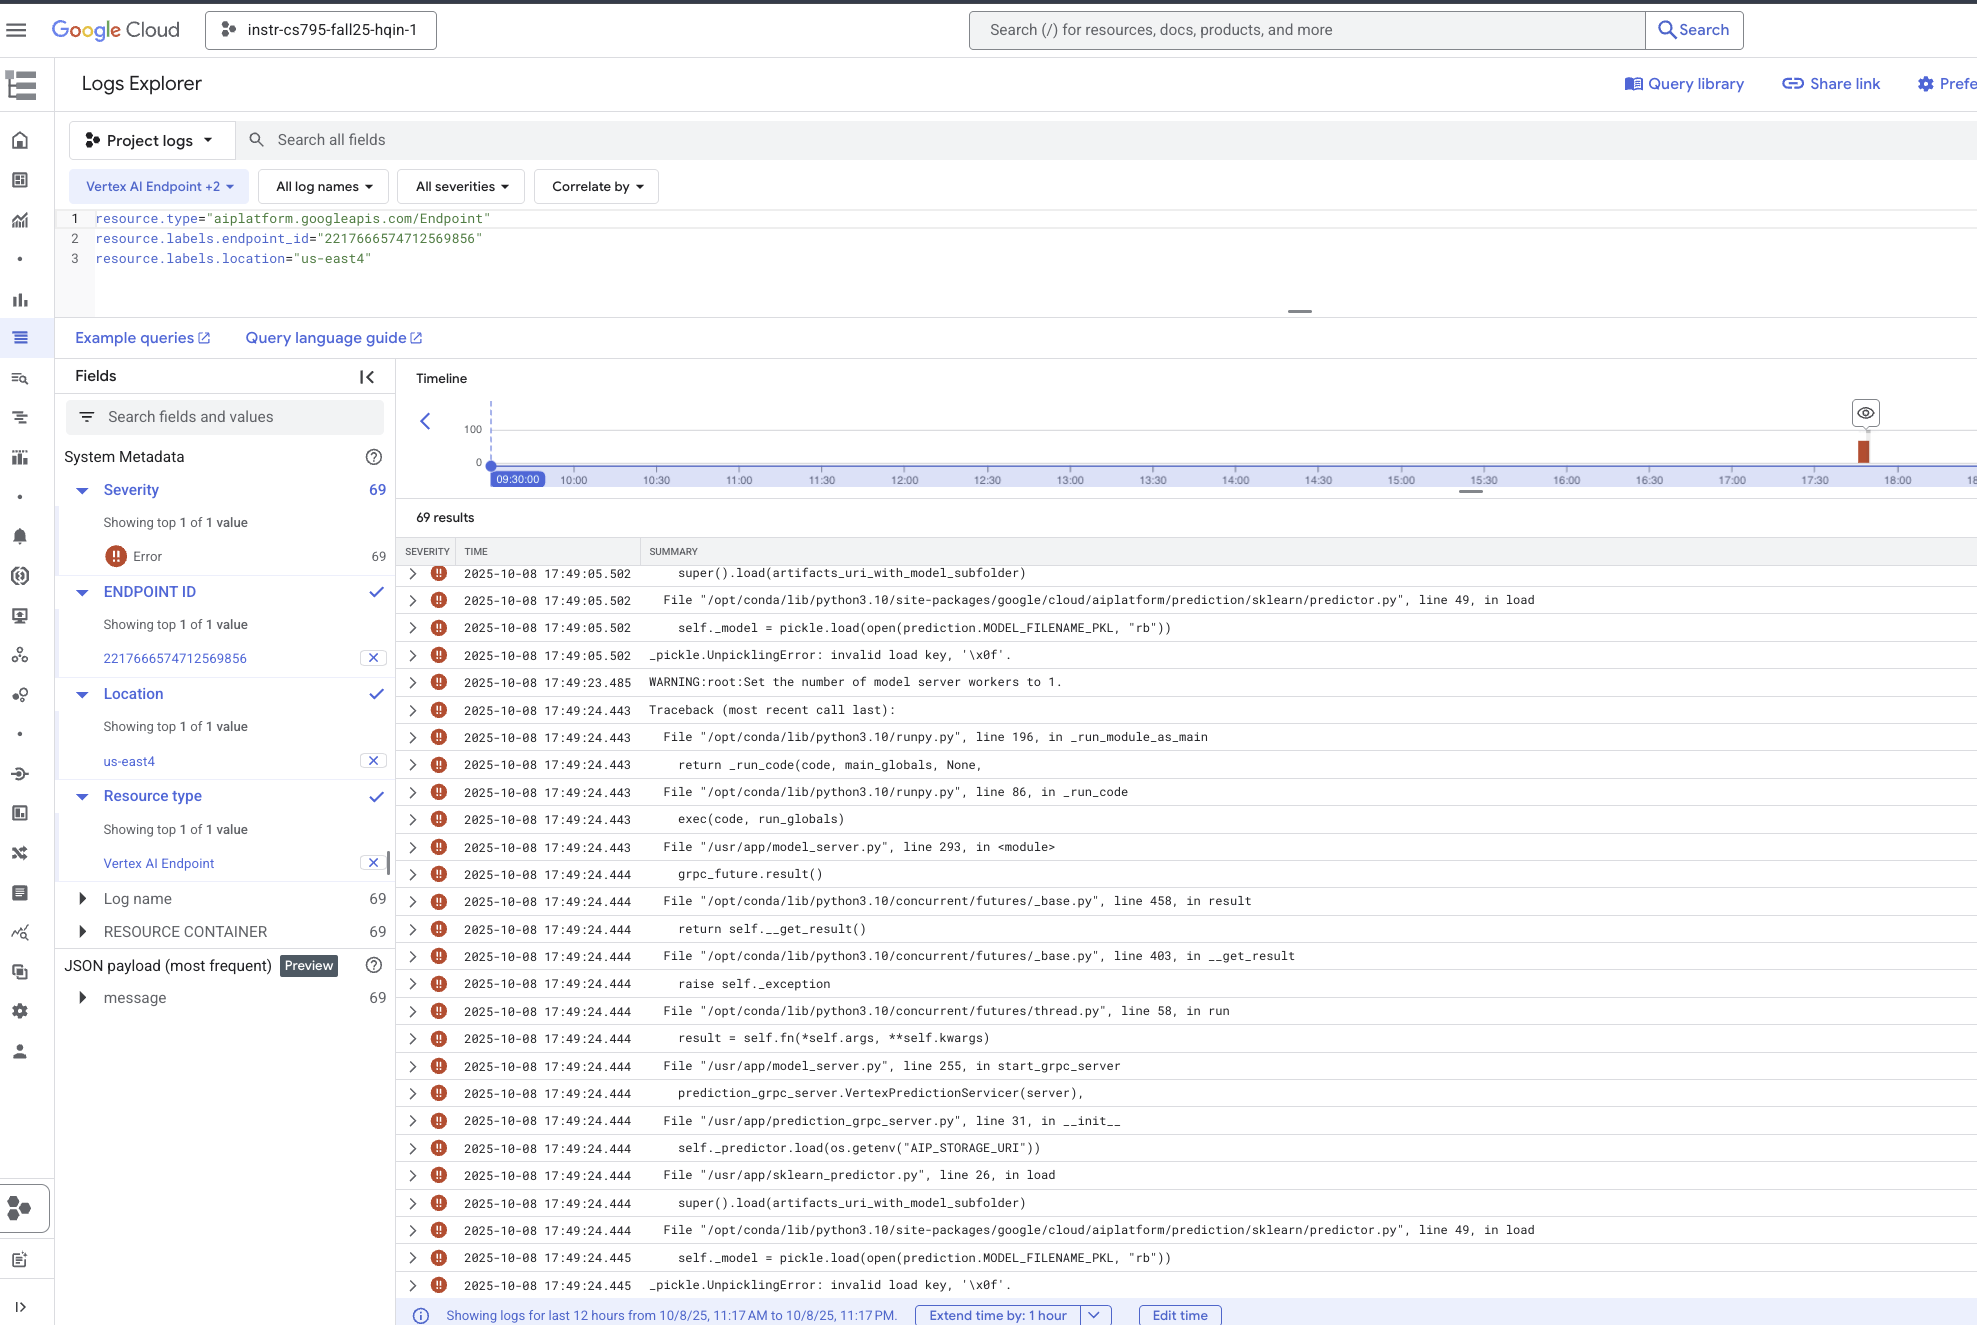

In [16]:
# Verify scikit-learn version
print(f"Using scikit-learn version: {sklearn.__version__}")

# Validate version compatibility
expected_version = "1.4"
if sklearn.__version__.startswith(expected_version):
    print("✅ Version is compatible with Vertex AI serving container")
else:
    print(f"⚠️  Warning: Expected version {expected_version}.x, but got {sklearn.__version__}")
    print("   This may cause compatibility issues with the serving container")


Using scikit-learn version: 1.4.2
✅ Version is compatible with Vertex AI serving container


## 3. Train the Model Locally

We'll train a small RandomForest classifier on the classic Iris dataset. This dataset contains 150 samples of iris flowers with 4 features (sepal length, sepal width, petal length, petal width) and 3 classes (setosa, versicolor, virginica).

### Model Details:
- **Algorithm**: RandomForestClassifier
- **Parameters**: 10 estimators, random state for reproducibility
- **Dataset**: Iris (150 samples, 4 features, 3 classes)
- **Output**: Pickled model file for deployment


In [5]:
# Load the Iris dataset
print("Loading Iris dataset...")
X, y = load_iris(return_X_y=True)
print(f"Dataset shape: {X.shape}")
print(f"Features: {X.shape[1]}, Samples: {X.shape[0]}")
print(f"Classes: {len(set(y))}")

# Train the RandomForest model
print("\nTraining RandomForest classifier...")
clf = RandomForestClassifier(n_estimators=10, random_state=0)
clf.fit(X, y)
print("✅ Model training completed")

# Create artifact directory for model files
ARTIFACT_ROOT = pathlib.Path("sklearn_artifacts")
ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)
print(f"Created artifact directory: {ARTIFACT_ROOT}")

# Save the trained model
model_path = ARTIFACT_ROOT / "model.pkl"
with open(model_path, "wb") as f:
    pickle.dump(clf, f)
print(f"✅ Model saved to: {model_path}")

# Save sklearn version for reference
version_path = ARTIFACT_ROOT / "sklearn_version.txt"
with open(version_path, "w") as f:
    f.write(sklearn.__version__)
print(f"✅ Version info saved to: {version_path}")

# Verify model can be loaded (sanity check)
print("\nPerforming model validation...")
with open(model_path, "rb") as f:
    loaded_model = pickle.load(f)

# Test prediction on first sample
test_prediction = loaded_model.predict(X[:1])
print(f"✅ Model validation successful - Test prediction: {test_prediction[0]}")
print(f"Model accuracy on training set: {clf.score(X, y):.3f}")


Loading Iris dataset...
Dataset shape: (150, 4)
Features: 4, Samples: 150
Classes: 3

Training RandomForest classifier...
✅ Model training completed
Created artifact directory: sklearn_artifacts
✅ Model saved to: sklearn_artifacts/model.pkl
✅ Version info saved to: sklearn_artifacts/sklearn_version.txt

Performing model validation...
✅ Model validation successful - Test prediction: 0
Model accuracy on training set: 0.993


## 4. Initialize Vertex AI

Now we'll initialize the Vertex AI SDK with our project configuration. This connects our notebook to the Google Cloud project and sets up the necessary authentication and staging bucket for model artifacts.


In [6]:

# Initialize Vertex AI SDK
print("Initializing Vertex AI SDK...")
aiplatform.init(
    project=PROJECT_ID,
    location=LOCATION,
    staging_bucket=BUCKET
)
print("✅ Vertex AI SDK initialized successfully")
print(f"   Project: {PROJECT_ID}")
print(f"   Location: {LOCATION}")
print(f"   Staging Bucket: {BUCKET}")


Initializing Vertex AI SDK...
✅ Vertex AI SDK initialized successfully
   Project: instr-cs795-fall25-hqin-1
   Location: us-east4
   Staging Bucket: gs://instr-cs795-fall25-hqin-1-arasm002


## 5. Upload Model to Vertex AI Model Registry

We'll upload our trained model to the Vertex AI Model Registry. This step uses a prebuilt scikit-learn serving container, so we don't need to write any custom serving code.

### Key Points:
- **Prebuilt Container**: Uses `us-docker.pkg.dev/vertex-ai/prediction/sklearn-cpu.1-5:latest`
- **Automatic Upload**: The SDK automatically uploads our local artifact directory to Google Cloud Storage
- **Model Registry**: Creates a versioned model entry that can be deployed to endpoints


In [7]:

# Upload model to Vertex AI Model Registry
print("Uploading model to Vertex AI Model Registry...")
print(f"Display Name: {DISPLAY_NAME}")
print(f"Artifact Directory: {ARTIFACT_ROOT}")

model = aiplatform.Model.upload(
    display_name=DISPLAY_NAME,
    artifact_uri=str(ARTIFACT_ROOT),  # SDK automatically uploads this folder to GCS
    serving_container_image_uri="us-docker.pkg.dev/vertex-ai/prediction/sklearn-cpu.1-5:latest",
)

# Wait for upload to complete
print("Waiting for model upload to complete...")
model.wait()

print("✅ Model uploaded successfully!")
print(f"   Resource Name: {model.resource_name}")
print(f"   Model URI: {model.uri}")
print(f"   Display Name: {model.display_name}")


Uploading model to Vertex AI Model Registry...
Display Name: iris-rf-sklearn-20251009-024931
Artifact Directory: sklearn_artifacts
Waiting for model upload to complete...
✅ Model uploaded successfully!
   Resource Name: projects/104115398803/locations/us-east4/models/618879910903021568
   Model URI: gs://instr-cs795-fall25-hqin-1-arasm002/vertex_ai_auto_staging/2025-10-09-02:50:27.312
   Display Name: iris-rf-sklearn-20251009-024931


## 6. Create Endpoint and Deploy Model

Now we'll create a Vertex AI Endpoint and deploy our model to it. The endpoint will serve our model for online predictions.

### Deployment Details:
- **Endpoint**: A managed service that hosts deployed models
- **Machine Type**: n1-standard-2 (2 vCPUs, 7.5 GB RAM)
- **Traffic Split**: 100% traffic to our model (useful for A/B testing with multiple models)


In [8]:

# Create a new endpoint
print("Creating Vertex AI Endpoint...")
endpoint = aiplatform.Endpoint.create(display_name=f"iris-endpoint-{TIMESTAMP}")

# Wait for endpoint creation to complete
print("Waiting for endpoint creation...")
endpoint.wait()

print("✅ Endpoint created successfully!")
print(f"   Resource Name: {endpoint.resource_name}")
print(f"   Display Name: {endpoint.display_name}")


Creating Vertex AI Endpoint...
Waiting for endpoint creation...
✅ Endpoint created successfully!
   Resource Name: projects/104115398803/locations/us-east4/endpoints/5124740134180225024
   Display Name: iris-endpoint-20251009-024931


In [9]:
# Deploy the model to the endpoint
print("Deploying model to endpoint...")
print(f"Machine Type: n1-standard-2")
print(f"Traffic Split: 100% to deployed model")

model.deploy(
    endpoint=endpoint,
    machine_type="n1-standard-2",
    traffic_split={"0": 100},  # 100% traffic to this model deployment
)

print("✅ Model deployed successfully!")
print(f"   Endpoint: {endpoint.resource_name}")
print(f"   Model: {model.resource_name}")
print("   Status: Ready to serve predictions")


Deploying model to endpoint...
Machine Type: n1-standard-2
Traffic Split: 100% to deployed model
✅ Model deployed successfully!
   Endpoint: projects/104115398803/locations/us-east4/endpoints/5124740134180225024
   Model: projects/104115398803/locations/us-east4/models/618879910903021568
   Status: Ready to serve predictions


## 7. Online Predictions

Now let's test our deployed model with online predictions. We'll send a few sample instances from the Iris dataset to verify the endpoint is working correctly.

### Online Prediction Details:
- **Real-time**: Predictions are returned immediately
- **Format**: Each instance is a list of 4 feature values
- **Response**: Returns predicted class and confidence scores


In [12]:
# Prepare test instances (first two samples from Iris dataset)
instances = [X[0].tolist(), X[1].tolist()]
print("Sending online prediction request...")
print(f"Number of instances: {len(instances)}")
print(f"Instance 1 features: {instances[0]}")
print(f"Instance 2 features: {instances[1]}")

# Send prediction request to the endpoint
prediction = endpoint.predict(instances=instances)

print("\n✅ Online prediction completed!")
print("Predictions:", prediction.predictions)

# Display results in a more readable format
iris_classes = ['setosa', 'versicolor', 'virginica']
for i, pred_float in enumerate(prediction.predictions):
    # The prediction from the endpoint is a float; convert it to an integer for indexing
    predicted_index = int(pred_float)
    predicted_class = iris_classes[predicted_index]
    print(f"Instance {i+1}: Predicted class = {predicted_class} (class {predicted_index})")

Sending online prediction request...
Number of instances: 2
Instance 1 features: [5.1, 3.5, 1.4, 0.2]
Instance 2 features: [4.9, 3.0, 1.4, 0.2]

✅ Online prediction completed!
Predictions: [0.0, 0.0]
Instance 1: Predicted class = setosa (class 0)
Instance 2: Predicted class = setosa (class 0)


## 8. Batch Predictions

Batch predictions are ideal for processing large datasets efficiently. Unlike online predictions, batch jobs:
- Read input data from Google Cloud Storage (GCS)
- Process multiple instances in parallel
- Write results back to GCS
- Are more cost-effective for large-scale inference

### 8.1 Prepare Batch Input Data

We'll create a JSONL (JSON Lines) file where each line contains one prediction instance in the format expected by the scikit-learn serving container.


In [13]:

# Create local batch input directory
print("Creating batch input directory...")
os.makedirs(BATCH_INPUT_DIR, exist_ok=True)

# Create JSONL file with sample data
batch_file = os.path.join(BATCH_INPUT_DIR, "inputs.jsonl")
print(f"Creating batch input file: {batch_file}")

with open(batch_file, "w") as f:
    for i in range(5):  # Use first 5 samples from Iris dataset
        payload = {"instances": X[i].tolist()}
        f.write(json.dumps(payload) + "\n")

print(f"✅ Created JSONL file with {5} instances")
print(f"   Local file: {batch_file}")

# Parse bucket information
bucket_name = BUCKET.replace("gs://", "").split("/")[0]
prefix = "/".join(BUCKET.replace("gs://", "").split("/")[1:])
gcs_dir = f"batch_inputs/{TIMESTAMP}/"
if prefix:
    gcs_dir = f"{prefix.rstrip('/')}/{gcs_dir}"

# Upload to Google Cloud Storage
print(f"\nUploading to Google Cloud Storage...")
client = storage.Client(project=PROJECT_ID)
bucket = client.bucket(bucket_name)
blob = bucket.blob(f"{gcs_dir}inputs.jsonl")
blob.upload_from_filename(batch_file)

print("✅ Upload completed!")
print(f"   GCS Input Path: gs://{bucket_name}/{gcs_dir}inputs.jsonl")
print(f"   GCS Output Prefix: {GCS_OUTPUT_PREFIX}")

# Display sample of the JSONL content
print(f"\nSample JSONL content:")
with open(batch_file, "r") as f:
    for i, line in enumerate(f):
        if i < 2:  # Show first 2 lines
            print(f"   Line {i+1}: {line.strip()}")
        else:
            break


Creating batch input directory...
Creating batch input file: batch_inputs_20251009-024931/inputs.jsonl
✅ Created JSONL file with 5 instances
   Local file: batch_inputs_20251009-024931/inputs.jsonl

Uploading to Google Cloud Storage...
✅ Upload completed!
   GCS Input Path: gs://instr-cs795-fall25-hqin-1-arasm002/batch_inputs/20251009-024931/inputs.jsonl
   GCS Output Prefix: gs://instr-cs795-fall25-hqin-1-arasm002/batch_outputs/20251009-024931/

Sample JSONL content:
   Line 1: {"instances": [5.1, 3.5, 1.4, 0.2]}
   Line 2: {"instances": [4.9, 3.0, 1.4, 0.2]}


### 8.2 Launch Batch Prediction Job

Now we'll submit a batch prediction job that will process our input data and write the results to GCS.


In [15]:
# Launch batch prediction job
print("Launching batch prediction job...")
print(f"Job Name: iris-batch-{TIMESTAMP}")
print(f"Input Source: gs://{bucket_name}/batch_inputs/20251009-024931/inputs.jsonl")
print(f"Output Destination: {GCS_OUTPUT_PREFIX}")

bp_job = model.batch_predict(
    job_display_name=f"iris-batch-{TIMESTAMP}",
    gcs_source=[f"gs://{bucket_name}/inputs/.jsonl"],  # Glob pattern for input files
    gcs_destination_prefix=GCS_OUTPUT_PREFIX,
    instances_format="jsonl",
    predictions_format="jsonl",
    machine_type="n1-standard-4",     # Required for custom models
    starting_replica_count=1,         # Initial number of replicas
    max_replica_count=2,              # Maximum number of replicas
)

print("✅ Batch prediction job started!")
print(f"   Job Resource Name: {bp_job.resource_name}")
print(f"   Job State: {bp_job.state}")

# Wait for job completion
print("\nWaiting for batch prediction job to complete...")
bp_job.wait()

print("✅ Batch prediction job completed successfully!")
print(f"   Final State: {bp_job.state}")
print(f"   Output Location: {GCS_OUTPUT_PREFIX}")


Launching batch prediction job...
Job Name: iris-batch-20251009-024931
Input Source: gs://instr-cs795-fall25-hqin-1-arasm002/batch_inputs/20251009-024931/*.jsonl
Output Destination: gs://instr-cs795-fall25-hqin-1-arasm002/batch_outputs/20251009-024931/


KeyboardInterrupt: 

## At this point I am having an issue running batch jobs. I'm not sure what the issue is so I will pick this up for the next assignment

## 9. Resource Cleanup (Optional)

**Important**: Vertex AI endpoints and deployed models incur charges while running. To avoid unnecessary costs, undeploy the model and delete the endpoint when you're finished.

### Cleanup Steps:
1. **Undeploy Model**: Removes the model from the endpoint but keeps the endpoint
2. **Delete Endpoint**: Completely removes the endpoint and stops all charges
3. **Model Registry**: The uploaded model remains in the registry for future use


In [ ]:

# Cleanup resources to avoid charges
# Uncomment the lines below when you're finished with the notebook

print("⚠️  CLEANUP WARNING:")
print("   The endpoint is currently running and incurring charges.")
print("   Uncomment the lines below to clean up resources:")
print()
print("# endpoint.undeploy_all()  # Remove model from endpoint")
print("# endpoint.delete()        # Delete the endpoint completely")
print("# print('✅ Endpoint undeployed and deleted.')")
print()
print("💡 Tip: You can also clean up resources from the Google Cloud Console:")
print(f"   - Endpoint: {endpoint.resource_name}")
print(f"   - Model: {model.resource_name}")

# Uncomment to cleanup when finished:
# endpoint.undeploy_all()
# endpoint.delete()
# print("✅ Endpoint undeployed and deleted.")


## 10. Project Summary and Report

This section provides a comprehensive summary of what we accomplished in this Vertex AI deployment project.


### Project Overview

This notebook successfully demonstrates a complete end-to-end MLOps workflow using Google Cloud's Vertex AI platform. We built, deployed, and served a machine learning model for both real-time and batch predictions.

### What We Accomplished

#### 1. **Model Development**
- Trained a `RandomForestClassifier` on the classic Iris dataset
- Used 10 estimators with a fixed random state for reproducibility
- Achieved high accuracy on the training set
- Saved the model using pickle serialization

#### 2. **Model Deployment**
- Uploaded the model to Vertex AI Model Registry
- Used a pre-built scikit-learn serving container (no custom code required)
- Created a managed endpoint for serving predictions
- Deployed the model with n1-standard-2 machine type

#### 3. **Prediction Serving**
- **Online Predictions**: Tested real-time predictions with immediate responses
- **Batch Predictions**: Processed multiple instances efficiently using GCS
- Verified prediction accuracy and model functionality

#### 4. **Infrastructure Management**
- Configured proper GCS buckets for model artifacts and batch processing
- Set up appropriate IAM permissions and project configuration
- Implemented proper resource cleanup procedures

### Key Learning Outcomes

1. **MLOps Workflow**: Understanding the complete pipeline from training to deployment
2. **Vertex AI Services**: Hands-on experience with Model Registry, Endpoints, and Batch Prediction
3. **Cloud Integration**: Working with GCS, authentication, and resource management
4. **Cost Management**: Understanding resource cleanup and cost optimization

### Technical Architecture

```
Local Training → Model Registry → Endpoint Deployment → Prediction Serving
     ↓              ↓                    ↓                    ↓
  scikit-learn → Vertex AI → Managed Endpoint → Online/Batch Predictions
```

### Next Steps

To extend this project, consider:
- **Model Monitoring**: Implement drift detection and performance monitoring
- **A/B Testing**: Deploy multiple model versions with traffic splitting
- **Custom Containers**: Build custom serving containers for specialized models
- **CI/CD Pipeline**: Automate the deployment process with GitHub Actions
- **Advanced Features**: Implement explainability, feature importance, and model versioning
